In [16]:
!pip install pillow

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#Exercise 1

##1.Read and Display Image


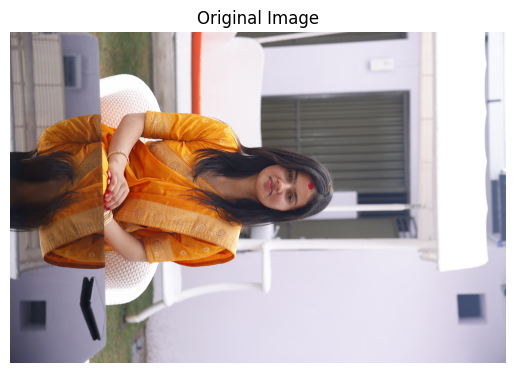

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.JPG')
plt.imshow(img)
plt.axis('off')
plt.title("Original Image")
plt.show()

##2.Display Top-Left 100*100 Pixels

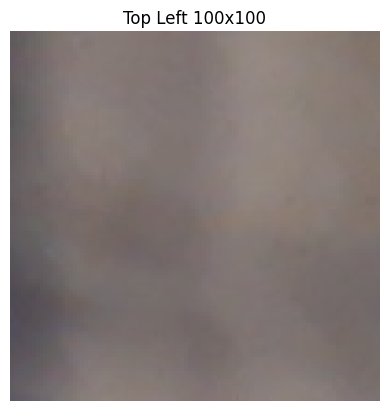

In [20]:
import numpy as np
img_array = np.array(img)

top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.axis('off')
plt.title("Top Left 100x100")
plt.show()

##3. Show R,G,B Chennels

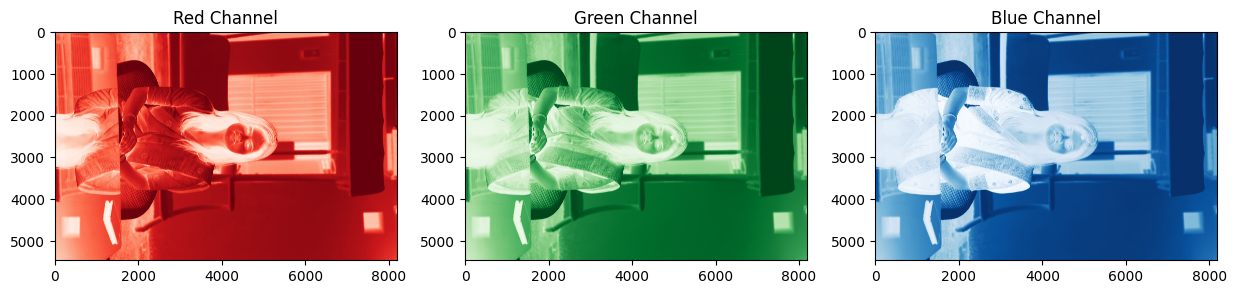

In [21]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")

plt.show()

##4. Modify Top 100*100 to 210

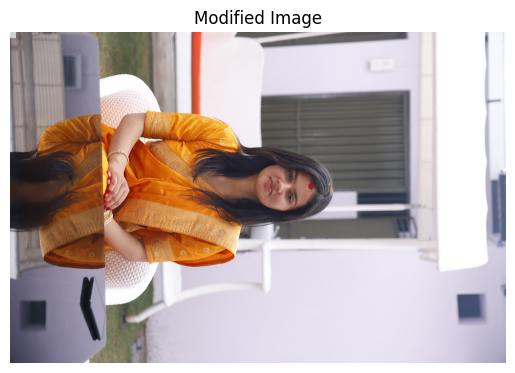

In [22]:
modified_img = img_array.copy()
modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.axis('off')
plt.title("Modified Image")
plt.show()

#Exercise2 - Grayscale Image

##1.Load Grayscale Image

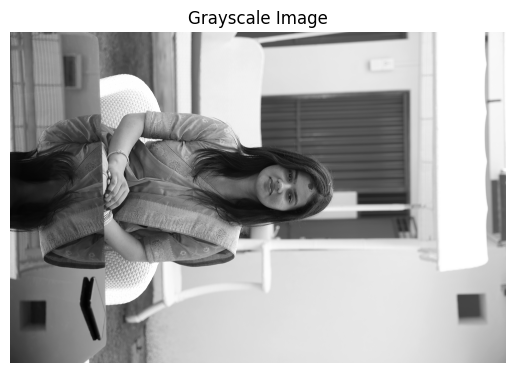

In [23]:
gray_img = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.JPG').convert('L')

plt.imshow(gray_img, cmap='gray')
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

##2.Extract Middle 150 Pixels

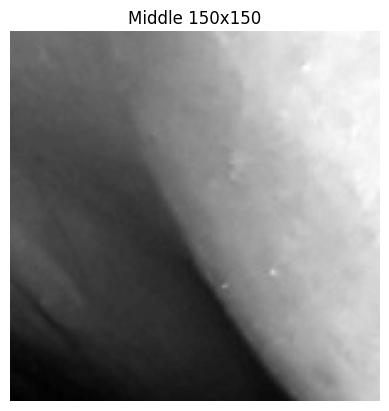

In [24]:
gray_array = np.array(gray_img)

h, w = gray_array.shape

middle = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(middle, cmap='gray')
plt.axis('off')
plt.title("Middle 150x150")
plt.show()

##3.Apply Threshold

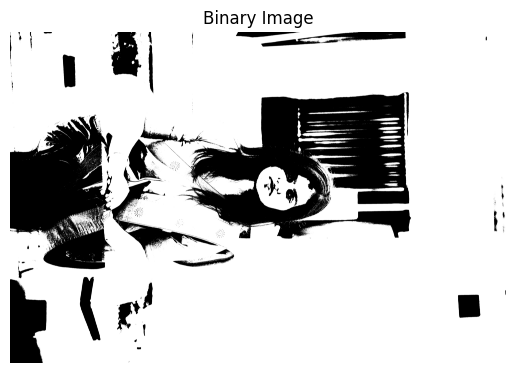

In [25]:
binary = gray_array.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.title("Binary Image")
plt.show()

##4.Rotate 90 degree clockwise

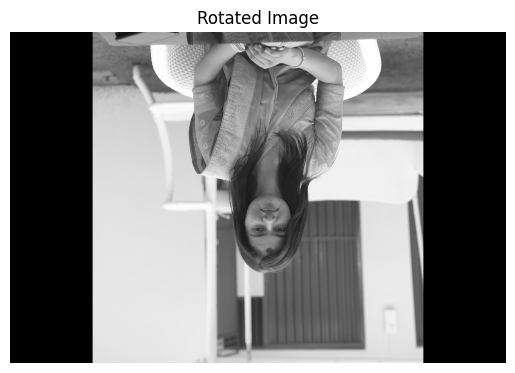

In [15]:
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap='gray')
plt.axis('off')
plt.title("Rotated Image")
plt.show()

##5.Convert Grayscale to RGB

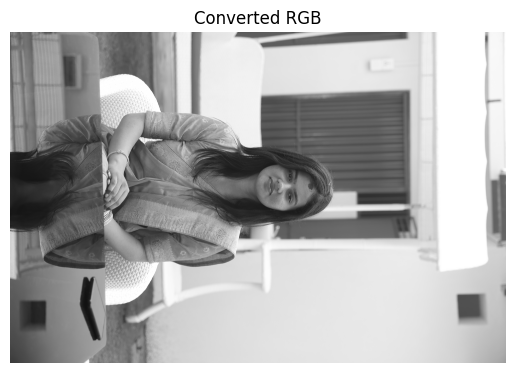

In [26]:
rgb_img = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.axis('off')
plt.title("Converted RGB")
plt.show()

#Exercise3

##STEP 1

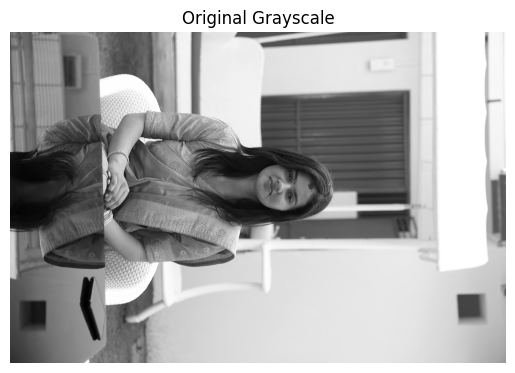

In [27]:
# Convert to grayscale first
gray_img = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.JPG').convert('L')
X = np.array(gray_img, dtype=float)

plt.imshow(X, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')
plt.show()

In [28]:
mean = np.mean(X, axis=0)
X_centered = X - mean

In [29]:
cov_matrix = np.cov(X_centered, rowvar=False)

##STEP2

In [30]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [31]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


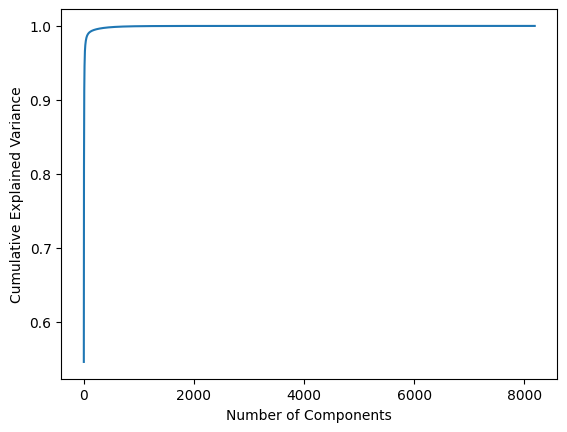

In [32]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

##STEP 3

In [33]:
def reconstruct(k):
    P = eigenvectors[:, :k]
    X_reduced = np.dot(X_centered, P)
    X_reconstructed = np.dot(X_reduced, P.T) + mean
    return X_reconstructed

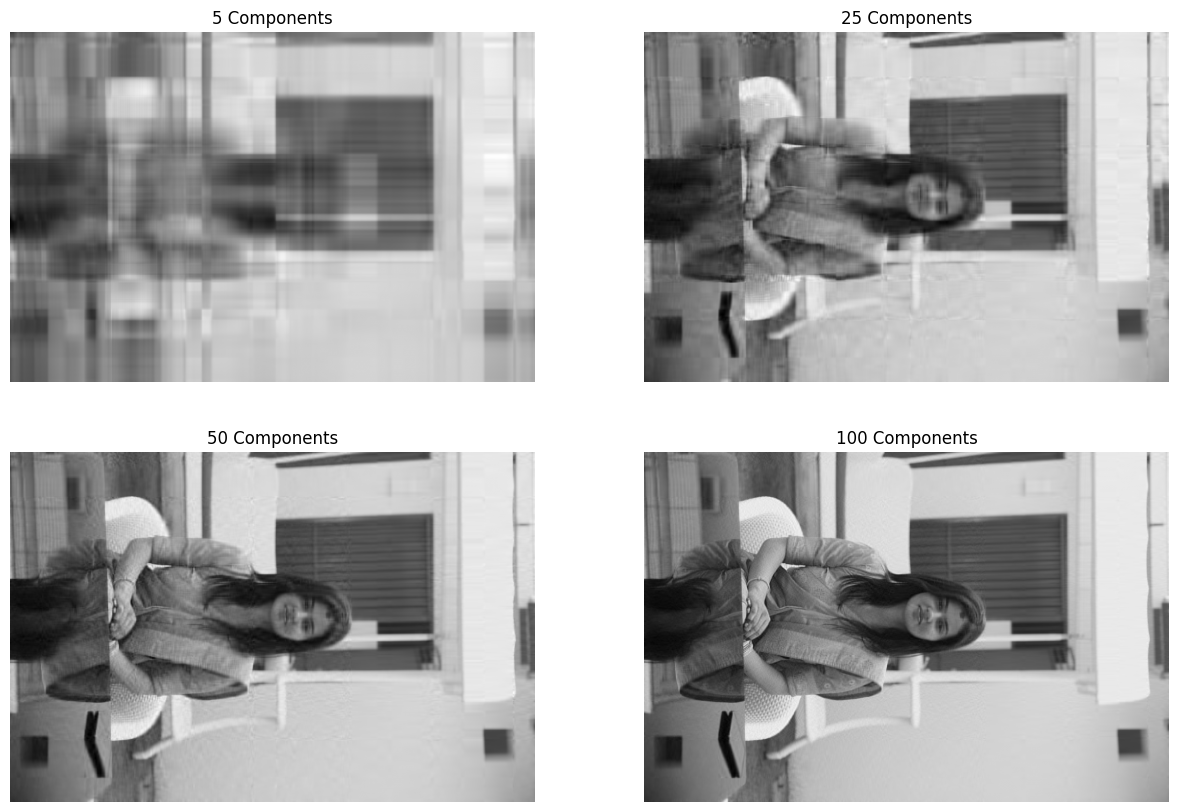

In [34]:
k_values = [5, 25, 50, 100]

plt.figure(figsize=(15,10))

for i, k in enumerate(k_values):
    img_recon = reconstruct(k)

    plt.subplot(2,2,i+1)
    plt.imshow(img_recon.real, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis('off')

plt.show()